In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("mieszkania_warszawa.csv")

df.head()

,id_oferty,dzielnica,metraz_m2,liczba_pokoi,pietro,rok_budowy,ma_balkon,ma_miejsce_parkingowe,odleglosc_od_centrum_km,cena_pln
0,10001,Białołęka,69.1,4,3,1995,True,False,4.52,948319.0
1,10002,Praga-Południe,29.9,1,4,2016,True,False,2.13,408287.0
2,10003,Wilanów,90.9,5,4,2005,True,True,14.62,1464602.0
3,10004,Targówek,29.8,2,3,2016,False,False,0.50,390717.0
4,10005,Ursynów,61.7,2,7,1997,True,False,6.38,764932.0


In [4]:
print("Rozmiar danych:")
print(df.shape)

print("\nInformacje o danych:")
print(df.info())

print("\nStatystyki opisowe:")
print(df.describe())

print("\nBraki danych:")
print(df.isnull().sum())

Rozmiar danych:
(2000, 10)

Informacje o danych:
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id_oferty                2000 non-null   int64  
 1   dzielnica                2000 non-null   str    
 2   metraz_m2                2000 non-null   float64
 3   liczba_pokoi             2000 non-null   int64  
 4   pietro                   2000 non-null   int64  
 5   rok_budowy               2000 non-null   int64  
 6   ma_balkon                2000 non-null   bool   
 7   ma_miejsce_parkingowe    2000 non-null   bool   
 8   odleglosc_od_centrum_km  2000 non-null   float64
 9   cena_pln                 2000 non-null   float64
dtypes: bool(2), float64(3), int64(4), str(1)
memory usage: 129.0 KB
None

Statystyki opisowe:
          id_oferty    metraz_m2  liczba_pokoi       pietro   rok_budowy  \
count   2000.000000  2000.000000   2

In [5]:
# Wstępne obserwacje

# Na pierwszy rzut oka dane wyglądają w większości poprawnie, ale widać kilka podejrzanych rzeczy:

# 1. W kolumnie `cena_pln` są bardzo duże wartości, więc mogą być outliery.
# 2. W kolumnie `metraz_m2` maksymalne wartości są bardzo wysokie, np. kilkaset m2.
# 3. W kolumnie `rok_budowy` są nielogiczne lata, np. bardzo stare albo z przyszłości.
# 4. Nie ma braków danych, więc nie trzeba uzupełniać NaN.

In [6]:
srednia = df["cena_pln"].mean()
mediana = df["cena_pln"].median()
odchylenie = df["cena_pln"].std()
skosnosc = df["cena_pln"].skew()
kurtoza = df["cena_pln"].kurt()

print("Statystyki dla cena_pln:")
print("Średnia:", srednia)
print("Mediana:", mediana)
print("Odchylenie standardowe:", odchylenie)
print("Skewness:", skosnosc)
print("Kurtosis:", kurtoza)

Statystyki dla cena_pln:
Średnia: 880961.205231117
Mediana: 809575.5
Odchylenie standardowe: 749976.280153556
Skewness: 15.858372951823213
Kurtosis: 404.2182639750827


In [7]:
# Komentarz do ceny

# Skewness dla `cena_pln` jest dodatni, więc rozkład jest prawostronnie skośny.

# Oznacza to, że większość mieszkań ma normalniejsze ceny, ale jest kilka bardzo drogich ofert, które ciągną rozkład w prawo.

In [8]:
Q1 = df["metraz_m2"].quantile(0.25)
Q3 = df["metraz_m2"].quantile(0.75)
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 40.8
Q3: 69.9
IQR: 29.10000000000001


In [9]:
print("Liczba unikalnych dzielnic:")
print(df["dzielnica"].nunique())

print("\nLiczba ofert w każdej dzielnicy:")
print(df["dzielnica"].value_counts())

Liczba unikalnych dzielnic:
11

Liczba ofert w każdej dzielnicy:
dzielnica
Mokotów           210
Targówek          189
Ursynów           189
Śródmieście       189
Ochota            188
Wola              178
Białołęka         177
Bemowo            176
Bielany           174
Praga-Południe    166
Wilanów           164
Name: count, dtype: int64


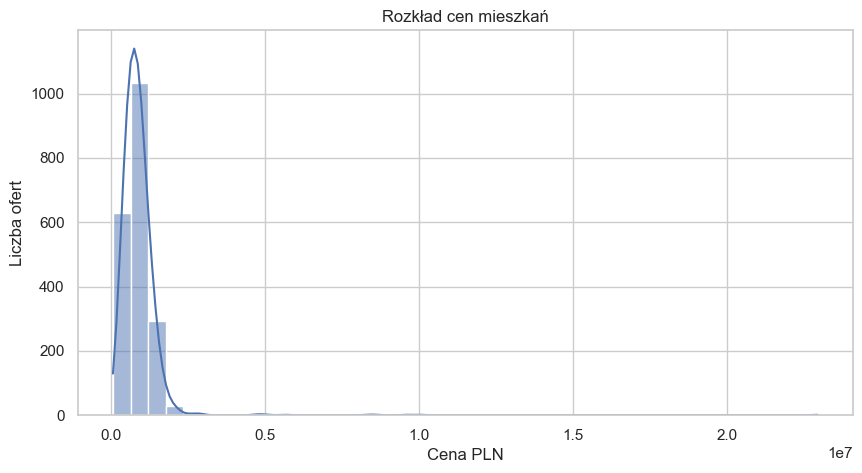

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(df["cena_pln"], bins=40, kde=True)

plt.title("Rozkład cen mieszkań")
plt.xlabel("Cena PLN")
plt.ylabel("Liczba ofert")
plt.show()

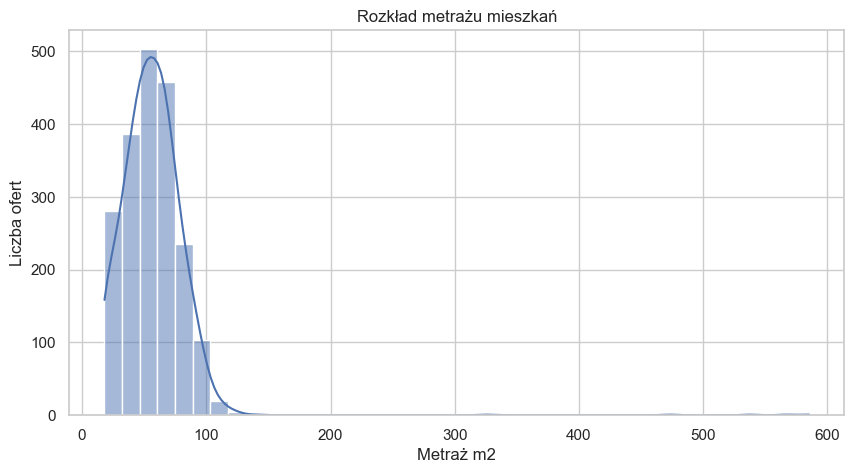

In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(df["metraz_m2"], bins=40, kde=True)

plt.title("Rozkład metrażu mieszkań")
plt.xlabel("Metraż m2")
plt.ylabel("Liczba ofert")
plt.show()

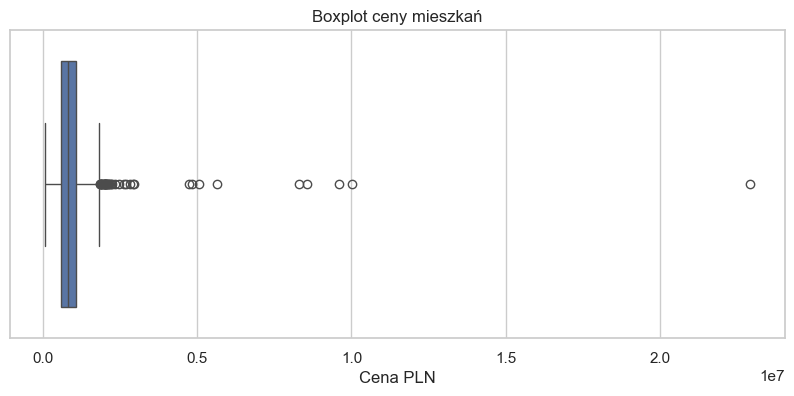

In [12]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["cena_pln"])

plt.title("Boxplot ceny mieszkań")
plt.xlabel("Cena PLN")
plt.show()

In [13]:
# Komentarz do boxplota

# Na boxplocie ceny widać dużo punktów poza wąsami, czyli wartości odstające.

# Najbardziej rzucają się w oczy bardzo drogie mieszkania. Mogą to być luksusowe oferty albo błędy w danych.

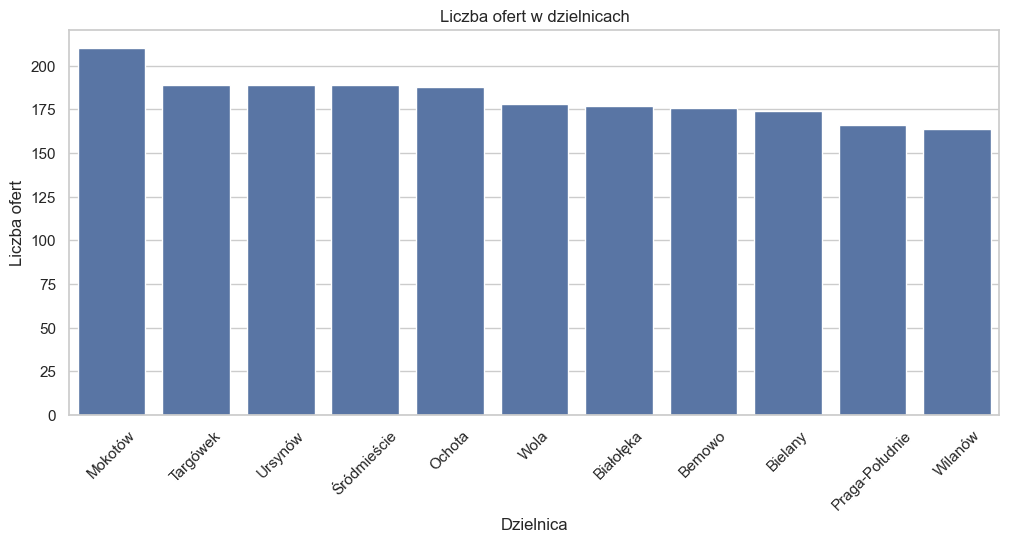

In [14]:
kolejnosc = df["dzielnica"].value_counts().index

plt.figure(figsize=(12, 5))
sns.countplot(data=df, x="dzielnica", order=kolejnosc)

plt.title("Liczba ofert w dzielnicach")
plt.xlabel("Dzielnica")
plt.ylabel("Liczba ofert")
plt.xticks(rotation=45)
plt.show()

In [15]:
df["cena_pln_per_m2"] = df["cena_pln"] / df["metraz_m2"]

df[["cena_pln", "metraz_m2", "cena_pln_per_m2"]].head()

,cena_pln,metraz_m2,cena_pln_per_m2
0,948319.0,69.1,13723.863965
1,408287.0,29.9,13655.083612
2,1464602.0,90.9,16112.233223
3,390717.0,29.8,13111.308725
4,764932.0,61.7,12397.601297


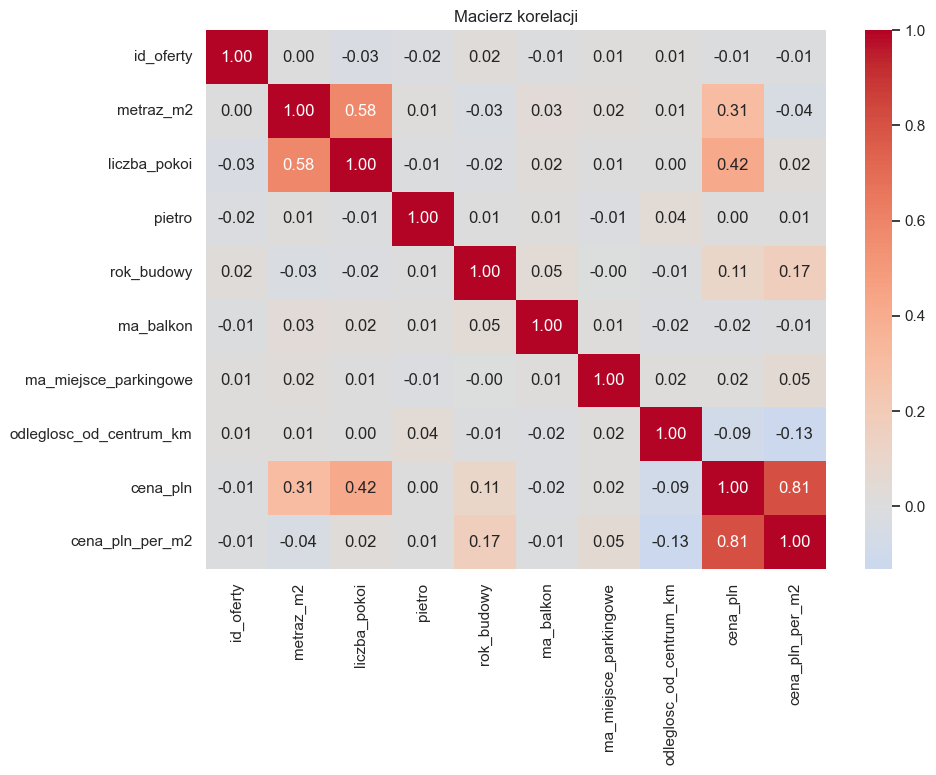

Korelacja z ceną:
cena_pln                   1.000000
cena_pln_per_m2            0.808618
liczba_pokoi               0.419491
metraz_m2                  0.310040
rok_budowy                 0.105799
ma_miejsce_parkingowe      0.017515
pietro                     0.004495
id_oferty                 -0.012569
ma_balkon                 -0.016987
odleglosc_od_centrum_km   -0.086266
Name: cena_pln, dtype: float64


In [16]:
df_corr = df.copy()

df_corr["ma_balkon"] = df_corr["ma_balkon"].astype(int)
df_corr["ma_miejsce_parkingowe"] = df_corr["ma_miejsce_parkingowe"].astype(int)

korelacje = df_corr.select_dtypes(include="number").corr()

plt.figure(figsize=(10, 7))
sns.heatmap(korelacje, annot=True, cmap="coolwarm", fmt=".2f", center=0)

plt.title("Macierz korelacji")
plt.show()

print("Korelacja z ceną:")
print(korelacje["cena_pln"].sort_values(ascending=False))

In [17]:
# Komentarz do korelacji

# Najsilniej z ceną mieszkania koreluje liczba pokoi i metraż.

# Jest to logiczne, bo większe mieszkania i mieszkania z większą liczbą pokoi zwykle są droższe.

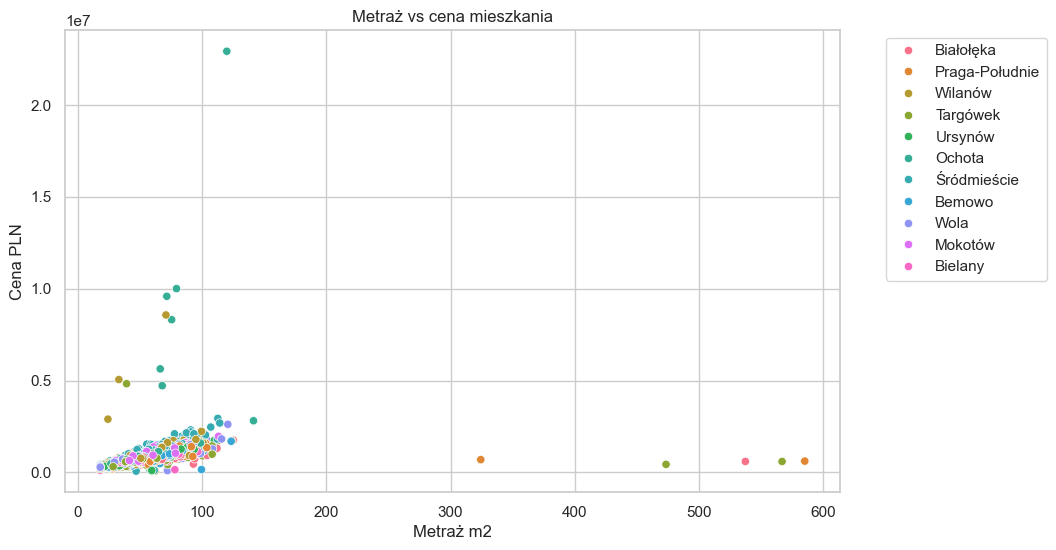

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="metraz_m2", y="cena_pln", hue="dzielnica")

plt.title("Metraż vs cena mieszkania")
plt.xlabel("Metraż m2")
plt.ylabel("Cena PLN")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

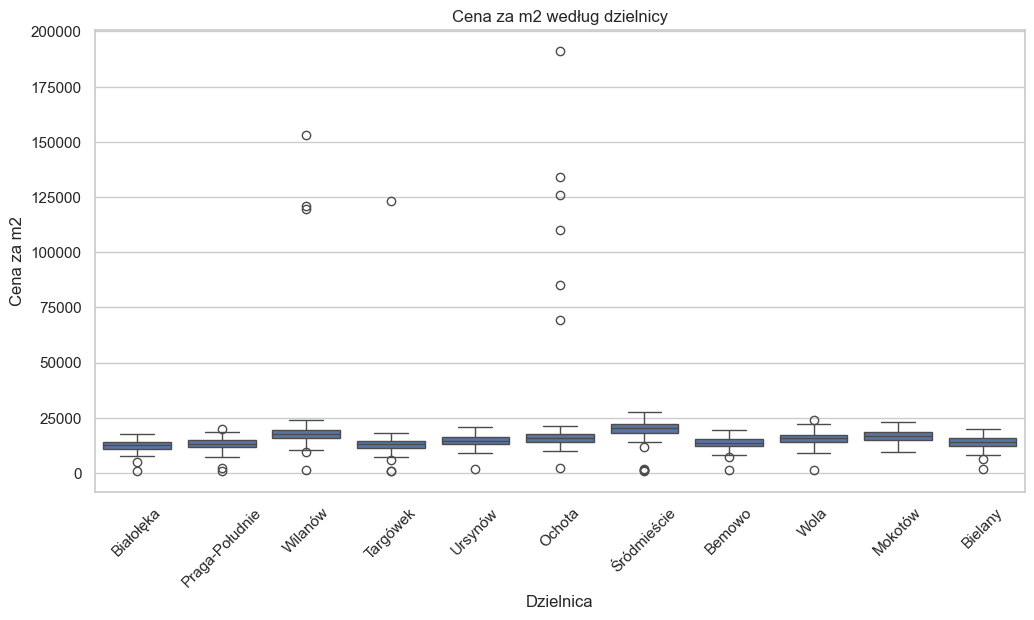

Mediana ceny za m2 według dzielnicy:
dzielnica
Śródmieście       20364.394427
Wilanów           17760.605769
Mokotów           16958.117813
Ochota            15769.885756
Wola              15768.543716
Ursynów           14681.719577
Bielany           14235.126046
Bemowo            13710.091367
Praga-Południe    13262.083586
Targówek          12975.338491
Białołęka         12599.354067
Name: cena_pln_per_m2, dtype: float64


In [19]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="dzielnica", y="cena_pln_per_m2")

plt.title("Cena za m2 według dzielnicy")
plt.xlabel("Dzielnica")
plt.ylabel("Cena za m2")
plt.xticks(rotation=45)
plt.show()

print("Mediana ceny za m2 według dzielnicy:")
print(df.groupby("dzielnica")["cena_pln_per_m2"].median().sort_values(ascending=False))

In [20]:
# Komentarz do ceny za m2

# Najwyższe ceny za m2 ma Śródmieście.

# To ma sens, bo jest to centralna i droga lokalizacja w Warszawie.

In [21]:
def outliers_iqr(series, mnoznik=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    
    dolna_granica = Q1 - mnoznik * IQR
    gorna_granica = Q3 + mnoznik * IQR
    
    return (series < dolna_granica) | (series > gorna_granica)


def modified_zscore(series):
    mediana = series.median()
    mad = (series - mediana).abs().median()
    
    return 0.6745 * (series - mediana) / mad

In [22]:
# IQR
out_cena_iqr = outliers_iqr(df["cena_pln"])

# Z-score
z = stats.zscore(df["cena_pln"], nan_policy="omit")
out_cena_z = np.abs(z) > 3

# Modified Z-score
z_mod = modified_zscore(df["cena_pln"])
out_cena_mod = np.abs(z_mod) > 3.5

print("Outliery w cena_pln:")
print("IQR:", out_cena_iqr.sum())
print("Z-score:", out_cena_z.sum())
print("Modified Z-score:", out_cena_mod.sum())

Outliery w cena_pln:
IQR: 39
Z-score: 9
Modified Z-score: 22


In [23]:
out_metraz_iqr = outliers_iqr(df["metraz_m2"])

print("Liczba outlierów w metrażu metodą IQR:")
print(out_metraz_iqr.sum())

print("\nTop 5 największych metraży:")
print(df.sort_values("metraz_m2", ascending=False)[["id_oferty", "dzielnica", "metraz_m2", "cena_pln"]].head(5))

Liczba outlierów w metrażu metodą IQR:
13

Top 5 największych metraży:
      id_oferty       dzielnica   metraz_m2  cena_pln
1597      11598  Praga-Południe  585.187341  614202.0
1845      11846        Targówek  566.921693  593446.0
53        10054       Białołęka  537.356930  595626.0
1681      11682        Targówek  473.491995  436705.0
1050      11051  Praga-Południe  324.358377  693470.0


In [24]:
bledne_lata = df[(df["rok_budowy"] < 1900) | (df["rok_budowy"] > 2026)]

print("Liczba wierszy z błędnym rokiem budowy:")
print(len(bledne_lata))

bledne_lata[["id_oferty", "dzielnica", "rok_budowy", "metraz_m2", "cena_pln"]]

Liczba wierszy z błędnym rokiem budowy:
5


,id_oferty,dzielnica,rok_budowy,metraz_m2,cena_pln
237,10238,Targówek,1850,59.0,660629.0
557,10558,Ursynów,2050,45.5,568546.0
635,10636,Praga-Południe,1800,76.0,1323289.0
1030,11031,Praga-Południe,2050,55.5,723745.0
1954,11955,Wilanów,1800,72.1,1624939.0


In [25]:
# robię kopię, żeby oryginalne dane zostały bez zmian
df_clean = df.copy()

# usuwam wiersze z błędnym rokiem budowy
df_clean = df_clean[(df_clean["rok_budowy"] >= 1900) & (df_clean["rok_budowy"] <= 2026)]

# winsoryzacja ceny, czyli przycięcie bardzo małych i bardzo dużych wartości
dolny_limit = df_clean["cena_pln"].quantile(0.01)
gorny_limit = df_clean["cena_pln"].quantile(0.99)

df_clean["cena_pln_capped"] = df_clean["cena_pln"].clip(
    lower=dolny_limit,
    upper=gorny_limit
)

# logarytm ceny
df_clean["cena_pln_log"] = np.log1p(df_clean["cena_pln"])

print("Rozmiar przed czyszczeniem:", df.shape)
print("Rozmiar po czyszczeniu:", df_clean.shape)

Rozmiar przed czyszczeniem: (2000, 11)
Rozmiar po czyszczeniu: (1995, 13)


In [26]:
print("Skewness cena_pln przed log:")
print(df_clean["cena_pln"].skew())

print("\nSkewness cena_pln_log po log:")
print(df_clean["cena_pln_log"].skew())

Skewness cena_pln przed log:
15.858487305862825

Skewness cena_pln_log po log:
-0.24050400455486837


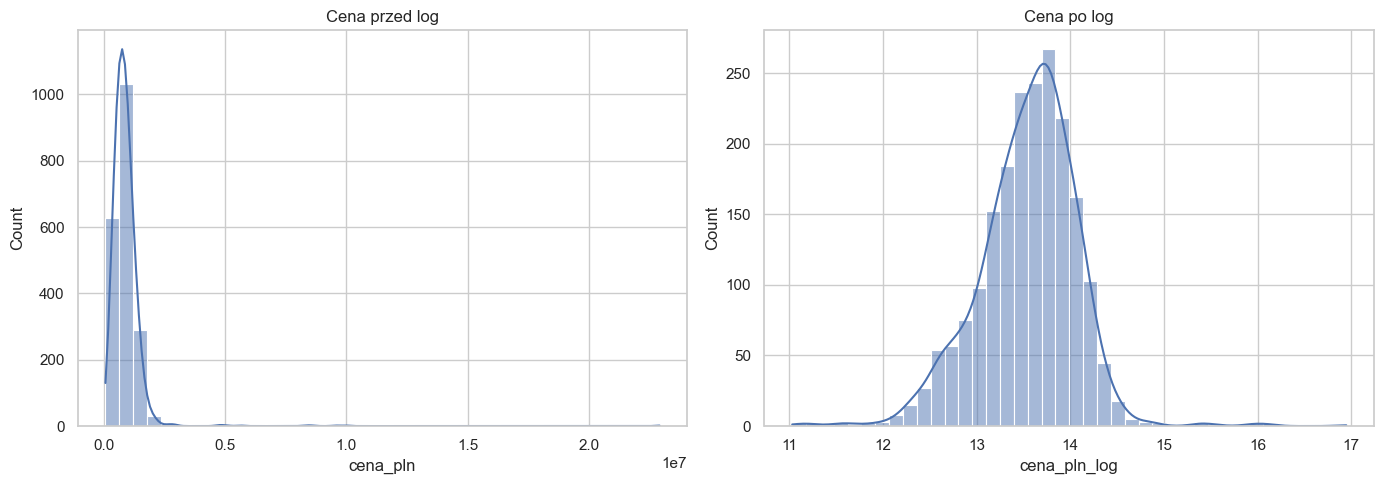

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_clean["cena_pln"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Cena przed log")

sns.histplot(df_clean["cena_pln_log"], bins=40, kde=True, ax=axes[1])
axes[1].set_title("Cena po log")

plt.tight_layout()
plt.show()

In [28]:
df_clean.to_csv("mieszkania_warszawa_clean.csv", index=False)

print("Zapisano plik: mieszkania_warszawa_clean.csv")

Zapisano plik: mieszkania_warszawa_clean.csv


In [29]:
# Wnioski

# 1. Ceny mieszkań w Warszawie są mocno prawostronnie skośne, bo jest kilka bardzo drogich ofert.
# 2. Największy wpływ na cenę ma metraż i liczba pokoi, co jest dość logiczne.
# 3. Najdroższą dzielnicą pod względem ceny za m2 jest Śródmieście.
# 4. W danych były outliery, np. bardzo wysokie ceny, bardzo duże metraże i błędne lata budowy.
# 5. Błędne lata budowy zostały usunięte, a ceny zostały dodatkowo przycięte metodą winsoryzacji.